# Week 4 Activity: Exploratory Data Analysis

In this worksheet you will:

1. inspect a cleaned dataset inside a GitHub repository
2. use an AI assistant to help you scope basic EDA questions
3. examine univariate distributions
4. analyse a categorical variable
5. plot relationships between numeric variables
6. calculate Pearson and Spearman correlations
7. change the plotting scale
8. compare relationships across groups
9. update the `README.md` with what you found


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

project_dir = Path("..").resolve()
data_path = project_dir / "data" / "clean" / "store_week_clean.csv"
output_dir = project_dir / "output"
output_dir.mkdir(parents=True, exist_ok=True)


## Part 1: First Look

Open the repository in VS Code and look at the folder structure.

Suggested AI prompt:

> Read the files in this repository. Tell me what each folder appears to contain, what the cleaned dataset might represent, and suggest five basic EDA questions I should start with.

Use the AI output as a starting point, not a substitute for checking the files yourself.


In [4]:
df = pd.read_csv(data_path)

df.head()


,week,store_id,store_type,region,promotion_flag,total_hours,avg_hourly_pay,weekly_sales,staffing_model
0,2025-01-05,CB01,CBD,North,Yes,38.0,39.00,10056.0,Heavy
1,2025-01-12,CB01,CBD,North,No,38.0,36.51,9786.0,Heavy
2,2025-01-19,CB01,CBD,North,No,29.0,36.50,7888.0,Standard
3,2025-01-26,CB01,CBD,North,No,37.0,37.00,10542.0,Heavy
4,2025-02-02,CB01,CBD,North,No,40.0,37.00,11277.0,Heavy


This dataset describes weekly performance for 20 stores over 20 weeks (starting January 2025). Each row is one store in one week. The numeric variables are `total_hours`, `avg_hourly_pay`, and `weekly_sales`. The categorical variables are `store_id`, `store_type`, `region`, `promotion_flag`, and `staffing_model`. The `week` column is time-related.

## Part 2: Numeric Distributions

Plot distributions for a few numeric variables, such as:

- `total_hours`
- `avg_hourly_pay`
- `weekly_sales`

Then briefly reflect on what you see.


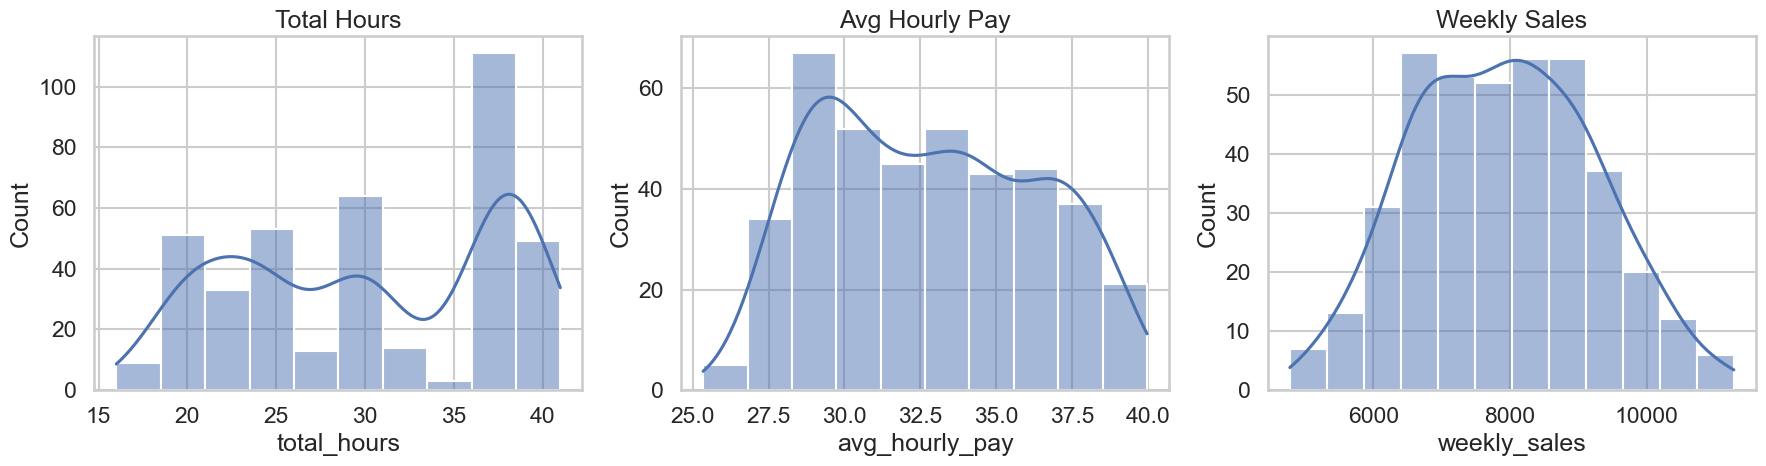

In [5]:
# Create a figure with 3 charts side by side (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Distribution of total_hours
sns.histplot(df["total_hours"], kde=True, ax=axes[0])
axes[0].set_title("Total Hours")

# Chart 2: Distribution of avg_hourly_pay
sns.histplot(df["avg_hourly_pay"], kde=True, ax=axes[1])
axes[1].set_title("Avg Hourly Pay")

# Chart 3: Distribution of weekly_sales
sns.histplot(df["weekly_sales"], kde=True, ax=axes[2])
axes[2].set_title("Weekly Sales")

plt.tight_layout()
plt.show()

total_hours appears spread out with no single clear peak, possibly reflecting different staffing levels across store types. avg_hourly_pay is slightly right-skewed, with most values clustered together but a few higher-paying outliers. weekly_sales is also right-skewed and bunched — most stores earn in a similar range, but some earn considerably more.


## Part 3: Composition of a Categorical Variable

Pick one categorical variable, such as `store_type`, `region`, or `promotion_flag`, and show its composition with a suitable plot.


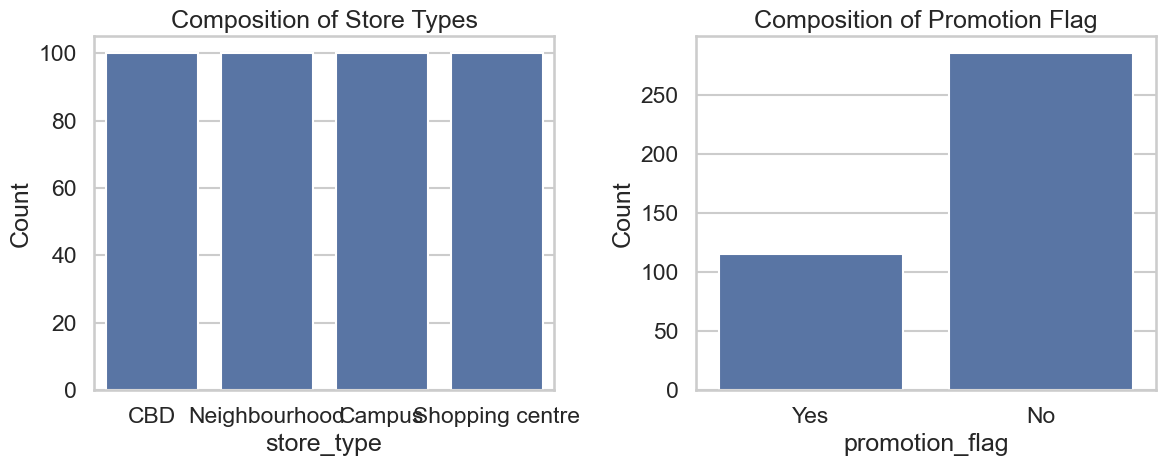

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='store_type', ax=axes[0])
axes[0].set_title('Composition of Store Types')
axes[0].set_ylabel('Count')

sns.countplot(data=df, x='promotion_flag', ax=axes[1])
axes[1].set_title('Composition of Promotion Flag')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


The composition tells us that the dataset is perfectly balanced across `store_type` and `region` (exactly 100 observations for each category), since the data tracks a fixed panel of 20 stores over 20 weeks. In contrast, `promotion_flag` shows that promotions are relatively rare compared to non-promotion weeks.


## Part 4: Scatter Plots and Correlations

Choose a pair of numeric variables and make at least one scatter plot.

Then calculate both:

- Pearson correlation
- Spearman correlation


In [ ]:
# Create a scatter plot to see the relationship between total_hours and weekly_sales
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='total_hours', y='weekly_sales')
plt.title('Total Hours vs Weekly Sales')
plt.xlabel('Total Hours Worked')
plt.ylabel('Weekly Sales ($)')
plt.show()


In [ ]:
# Calculate Pearson correlation (measures linear relationship)
pearson_corr = df['total_hours'].corr(df['weekly_sales'], method='pearson')
print(f"Pearson correlation: {pearson_corr:.3f}")

# Calculate Spearman correlation (measures rank/monotonic relationship)
spearman_corr = df['total_hours'].corr(df['weekly_sales'], method='spearman')
print(f"Spearman correlation: {spearman_corr:.3f}")


Yes, the plot and correlation coefficients tell the exact same story! The scatter plot shows a clear upward trend (more hours worked corresponds to strictly higher weekly sales). This is backed up by both the strong positive Pearson correlation (0.747, meaning the linear relationship is strong) and the Spearman correlation (0.737, meaning the ranking relationship is strongly preserved).


## Part 5: Change the Scale

Revisit one relationship and change the plotting scale. For example, try a log scale on the y-axis if the raw plot is hard to read.


In [ ]:
# Remake the scatter plot with a logarithmic scale on the y-axis
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='total_hours', y='weekly_sales')
plt.yscale('log')
plt.title('Total Hours vs Weekly Sales (Log Scale)')
plt.xlabel('Total Hours Worked')
plt.ylabel('Weekly Sales ($) - Log Scale')
plt.show()


What becomes clearer once you change the scale?

Using a log scale on the y-axis pulls apart the tightly bunched sales numbers at the lower end. We can now clearly see that the upward trend between hours worked and weekly sales isn't just driven by a few super high-earning outlier weeks; the strong relationship holds true even among the "normal" weeks at the bottom of the raw plot.


## Part 6: Plot by Group

Compare the same relationship across groups. For example:

- colour points by `store_type`
- facet by `region`
- compare distributions by `promotion_flag`


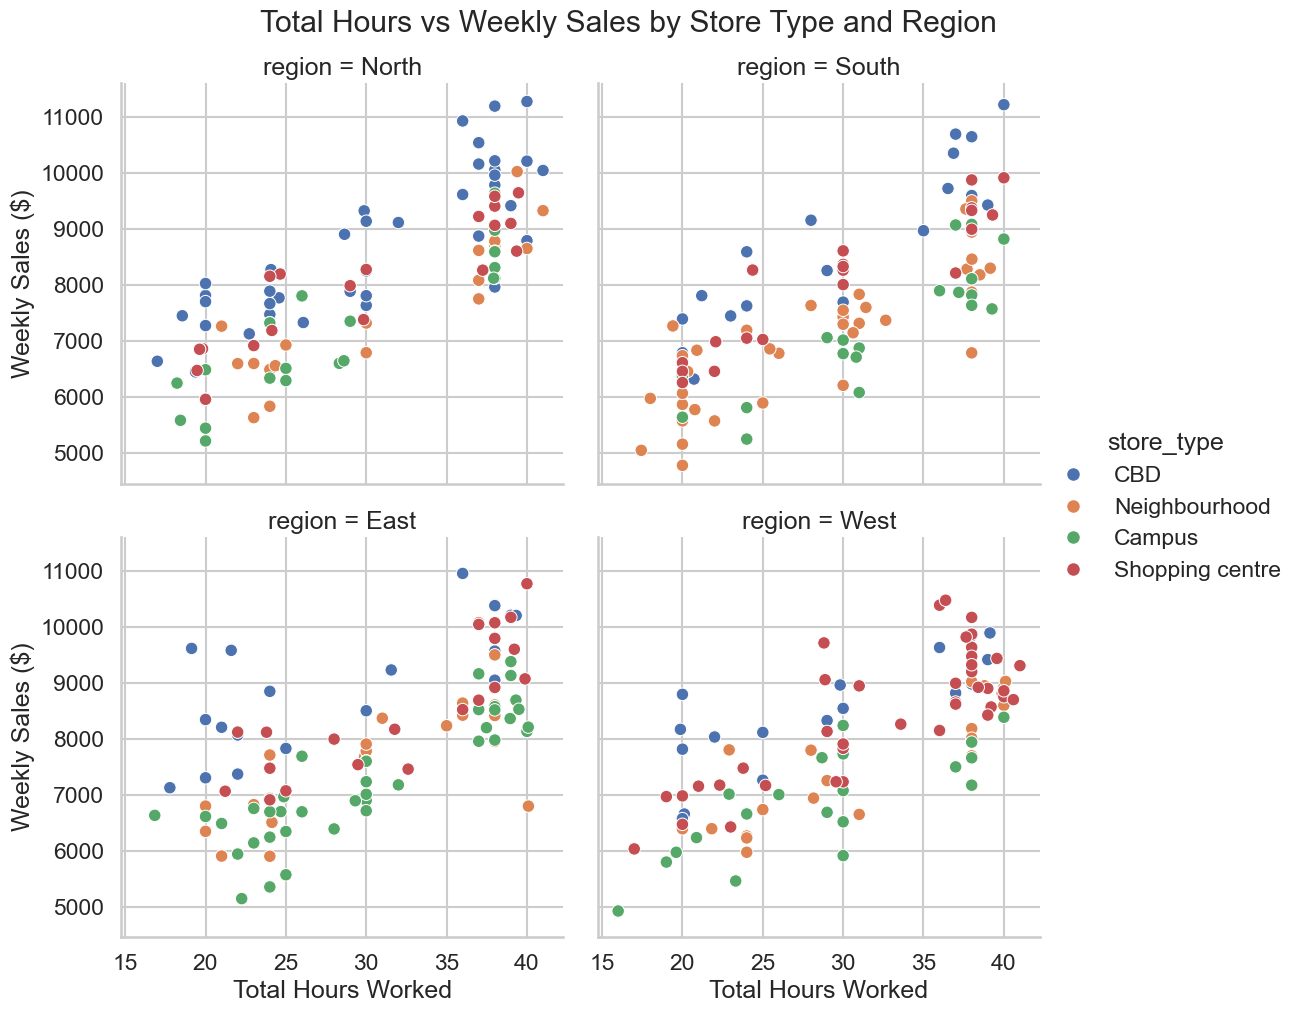

In [12]:
# Scatter plot of total_hours vs weekly_sales, coloured by store_type, faceted by region
g = sns.relplot(
    data=df,
    x='total_hours',
    y='weekly_sales',
    hue='store_type',       # colour each dot by store type
    col='region',           # one mini-plot per region
    col_wrap=2,             # wrap after 2 columns → gives a 2x2 grid
    height=5,
    aspect=1.1,
)
g.set_axis_labels('Total Hours Worked', 'Weekly Sales ($)')
g.figure.suptitle('Total Hours vs Weekly Sales by Store Type and Region', y=1.02)
plt.show()

Once the data is split by group, two things become clearer. First, **store types separate visually**: CBD stores (orange) tend to cluster at higher sales values for similar hours worked, while Campus stores sit lower — meaning store type matters for how much revenue an hour of labour generates. Second, the **positive relationship between hours and sales holds across all four regions**, but the spread differs — the East region shows a weaker, more scattered relationship (Pearson = 0.67) compared to North (0.81) and South (0.78), suggesting that factors beyond staffing hours play a bigger role in some regions than others.

## Part 7: Update the README

Update `README.md` so it describes:

- the folder structure
- the cleaned dataset
- the notebook you completed
- a few short bullet points summarising your EDA findings

You can draft the text here first if useful.


In [ ]:
# Optional: draft README bullet points here before copying them into README.md
